# When should a policy decide?

A decision schedule answers **when a policy may act**. Follow five calendars—
every period, every few periods, a delayed start, one opportunity, and known
irregular opportunities—then see how opportunities turn into actual orders.

The schedule controls timing. The policy chooses a quantity, constraints can
adjust what is accepted, and lead time controls when accepted stock arrives.
The schedule does not change demand or the engine's event sequence.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from stockcast import (
    PeriodicSchedule, OneTimeSchedule, ExplicitSchedule,
    PeriodicReviewPolicy, FixedPeriodicReviewTargets,
    InventoryStateDataFrame, SimulationEngine,
)

In [9]:
schedules = {
    "Every day": PeriodicSchedule(every=1),
    "Every 3 days": PeriodicSchedule(every=3),
    "Every 3 days, start at 2": PeriodicSchedule(every=3, start=2),
    "Once at 0": OneTimeSchedule(period=0),
    "Irregular: 0, 2, 6": ExplicitSchedule(periods=[0, 2, 6]),
}
periods = range(8)

## 1. See the opportunities

Period **0** is the first demand row in this run. On daily data these are days;
on weekly data they are weeks. `should_decide(t)` answers whether period `t` is
an opportunity. The schedule is deterministic: it does not inspect demand or
inventory. A dot means the policy may decide, not that it will order.

When there is no opportunity, demand and inventory still advance; only the
policy's ordering decision is skipped. At an opportunity, the policy sees the
pre-demand state and may still request zero.

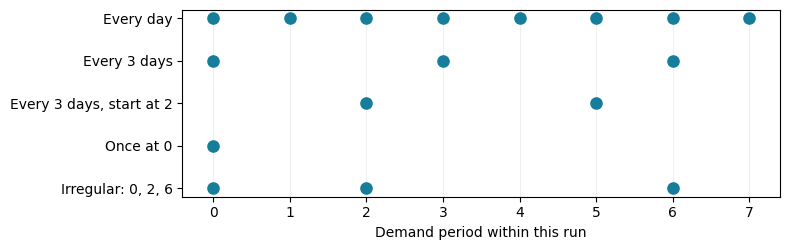

In [10]:
fig, ax = plt.subplots(figsize=(8, 2.6))
for row, (label, schedule) in enumerate(schedules.items()):
    eligible = [t for t in periods if schedule.should_decide(t)]
    ax.scatter(eligible, [row] * len(eligible), s=65, color="#167d9a")
ax.set(yticks=range(len(schedules)), yticklabels=list(schedules),
       xticks=list(periods), xlabel="Demand period within this run", xlim=(-0.4, 7.4))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

Read each row as a calendar of allowed decision periods: every day gives
`0–7`; every three days gives `0, 3, 6`; a start at 2 gives `2, 5`; the
one-time schedule gives only `0`; and the explicit schedule gives `0, 2, 6`.
The next section holds the policy and demand fixed so we can see what those
different opportunities change.

## 2. Run the same rule with different opportunities

Explicit teaching assumptions: one SKU, 8 daily demands of 2 units, opening
stock of 4, no pipeline, zero lead time, and lost sales. At each opportunity,
the policy orders up to 8 **only if inventory position is at most 2**. These
fixed planner thresholds make the decision visible; they are not estimated
quantiles or claimed optimal targets.

Changing the schedule alone isolates timing. In an operational model, revisit
the targets too: periodic order-up-to protection is `L+R`, while irregular
opportunities can require different coverage windows.

In [11]:
origin = pd.Timestamp("2026-01-01")
demand = pd.DataFrame({
    "unique_id": ["A"] * 8,
    "date": pd.date_range(origin + pd.Timedelta(days=1), periods=8, freq="D"),
    "y": [2.0] * 8,
    "period": list(periods),
})

def replay(**timing):
    policy = PeriodicReviewPolicy(
        lead_time=0, allow_backorders=False, **timing,
    ).fit(
        pd.DataFrame({"unique_id": ["A"]}),
        target_provider=FixedPeriodicReviewTargets(
            reorder_point=2.0, order_up_to_level=8.0,
        ),
        information_origin=origin, information_frequency="D",
    )
    opening = InventoryStateDataFrame(
        ["A"], max_lead_time=0, allow_backorders=False,
    ).initialize_zero(start_date=origin)
    opening.data["on_hand"] = 4.0
    return SimulationEngine().run(
        policy, demand, opening, n_periods=8,
        period_frequency="D", warmup_periods=0, scoring_periods=8,
        settlement_periods=0, order_during_settlement=False,
        demand_source_name="explicit_schedule_demo", random_seed=None,
    ).to_event_frame()

runs = {name: replay(schedule=schedule) for name, schedule in schedules.items()}
orders = pd.DataFrame({name: events.order_quantity.to_numpy()
                       for name, events in runs.items()}).T
orders.columns = pd.Index(periods, name="Demand period")
orders

Demand period,0,1,2,3,4,5,6,7
Every day,0.0,6.0,0.0,0.0,6.0,0.0,0.0,6.0
Every 3 days,0.0,0.0,0.0,8.0,0.0,0.0,6.0,0.0
"Every 3 days, start at 2",0.0,0.0,8.0,0.0,0.0,6.0,0.0,0.0
Once at 0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Irregular: 0, 2, 6",0.0,0.0,8.0,0.0,0.0,0.0,8.0,0.0


### Compare the inventory results

All five runs use the same eight demand days, opening stock, zero lead time,
and fixed policy thresholds. The event ledger records both opportunities and
accepted orders. This compact summary shows how often each schedule allowed a
decision, what was ordered, how much demand was served, and the resulting stock.


In [12]:
outcomes = pd.DataFrame([
    {
        "schedule": label,
        "opportunities": int(events["decision_flag"].sum()),
        "positive_orders": int((events["order_quantity"] > 0).sum()),
        "units_ordered": events["order_quantity"].sum(),
        "demand_served": f"{events['fulfilled_units'].sum():g}/{events['demand'].sum():g}",
        "lost_sales": events["lost_sales_units"].sum(),
        "mean_end_stock": round(events["ending_on_hand"].mean(), 1),
    }
    for label, events in runs.items()
])
print(outcomes.to_string(index=False))


                schedule  opportunities  positive_orders  units_ordered demand_served  lost_sales  mean_end_stock
               Every day              8                3           18.0         16/16         0.0             4.0
            Every 3 days              3                2           14.0         14/16         2.0             3.0
Every 3 days, start at 2              2                2           14.0         16/16         0.0             3.2
               Once at 0              1                0            0.0          4/16        12.0             0.2
      Irregular: 0, 2, 6              3                2           16.0         16/16         0.0             3.0


The shared-scale panels below make the stock paths comparable. The blue line is
physical stock **after** each day's demand. Grey dotted lines mark decision
opportunities, orange triangles identify days with a positive order, and red
crosses mark days with lost sales. Each triangle sits at that day's ending stock
level; its height is **not** the order quantity. The order table above gives
those quantities. With zero lead time, accepted orders arrive before same-day
demand.


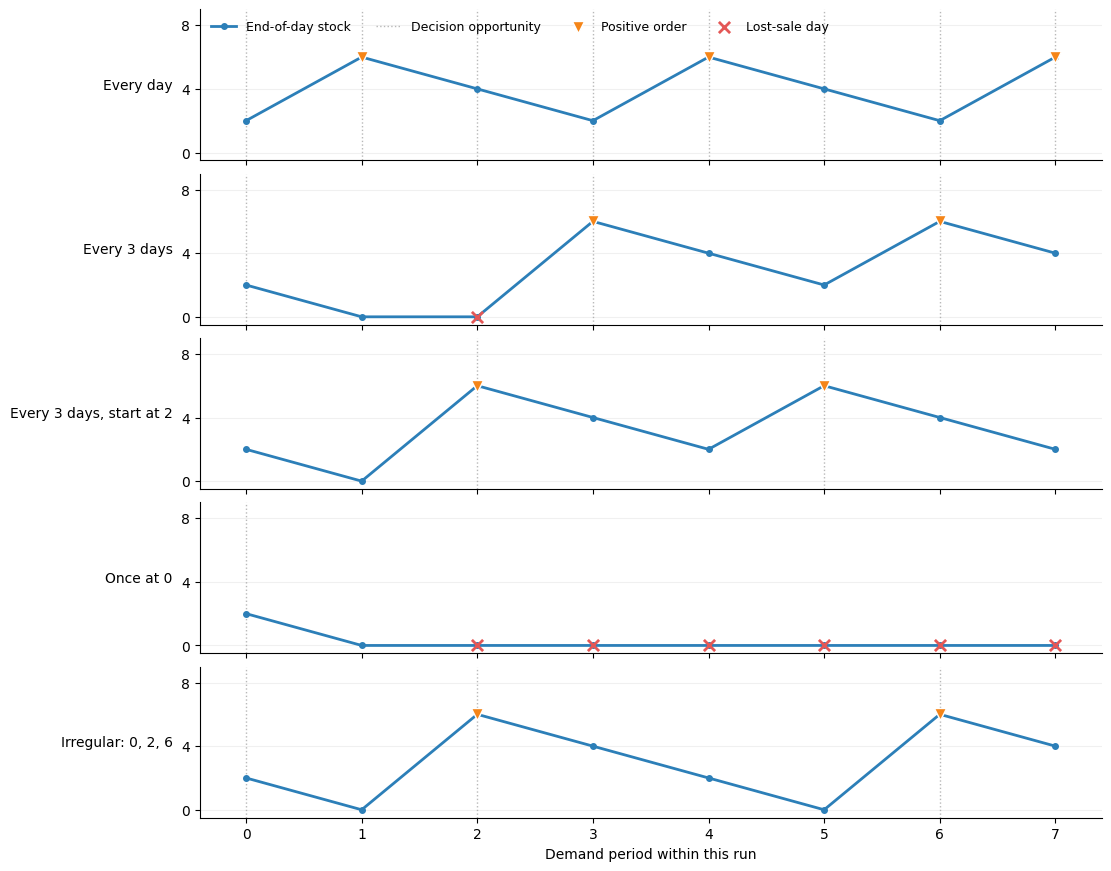

In [13]:
fig, axes = plt.subplots(
    len(runs), 1, figsize=(11, 8.6), sharex=True, sharey=True,
    layout="constrained",
)
for number, ((label, events), axis) in enumerate(zip(runs.items(), axes)):
    axis.plot(
        events["demand_period"], events["ending_on_hand"],
        color="#2C7FB8", marker="o", markersize=4, linewidth=2,
        label="End-of-day stock" if number == 0 else "_nolegend_",
    )
    opportunities = events.loc[events["decision_flag"], "demand_period"]
    for position, period in enumerate(opportunities):
        axis.axvline(
            period, color="#7F7F7F", linestyle=":", linewidth=1,
            alpha=0.55, zorder=1,
            label="Decision opportunity"
            if number == 0 and position == 0 else "_nolegend_",
        )
    order_days = events.loc[events["order_quantity"] > 0]
    axis.scatter(
        order_days["demand_period"], order_days["ending_on_hand"],
        marker="v", s=75, color="#F58518", edgecolor="white", zorder=5,
        label="Positive order" if number == 0 else "_nolegend_",
    )
    lost_days = events.loc[events["lost_sales_units"] > 0]
    axis.scatter(
        lost_days["demand_period"], lost_days["ending_on_hand"],
        marker="x", s=65, color="#E45756", linewidths=2, zorder=6,
        label="Lost-sale day" if number == 0 else "_nolegend_",
    )
    axis.set(ylabel=label, ylim=(-0.5, 9), yticks=[0, 4, 8])
    axis.yaxis.label.set(rotation=0, horizontalalignment="right", verticalalignment="center")
    axis.yaxis.set_label_coords(-0.03, 0.5)
    axis.grid(axis="y", alpha=0.18)
    axis.set_axisbelow(True)
    axis.spines[["top", "right"]].set_visible(False)
    if number == 0:
        axis.legend(frameon=False, ncol=4, loc="upper left", fontsize=9)
axes[-1].set(xlabel="Demand period within this run", xticks=list(periods), xlim=(-0.4, 7.4))
for axis in axes[:-1]:
    axis.tick_params(axis="x", labelbottom=False)
plt.show()


The two three-day schedules show why the starting period matters. With
`start=0`, the policy has an opportunity at period 0 but requests nothing:
opening stock of 4 exceeds the reorder point of 2. Its next opportunity is
period 3, after two units were lost at period 2. Starting at period 2 allows
an order before that demand, and this run serves all 16 units.

The one-time schedule also decides at period 0 and requests zero. It has no
later opportunity, so it cannot replenish as stock runs out. A one-time
schedule is not automatically a newsvendor policy; Notebook 04d uses an
explicit seasonal target with `SingleOrderPolicy`.

These outcomes describe one eight-day demand path with unchanged planner
thresholds. For an operational choice, build targets for each schedule's
actual coverage window, then compare service, stock, and costs on held-out
demand. The schedule changes when a policy can act; it does not calibrate that
policy's target.

## 3. No scheduler object required

For ordinary periodic use, pass `review_period`: it creates the same schedule
as `PeriodicSchedule(every=...)`. The following checks that `review_period=3`
produces identical event records to the explicit schedule. Use `review_period=1`
for an opportunity before every demand period. Supply either the shorthand or
an explicit schedule; the engine still needs a rule for when decisions are allowed.

In [14]:
without_schedule_object = replay(review_period=3)
pd.testing.assert_frame_equal(
    without_schedule_object, runs["Every 3 days"],
)
assert runs["Every 3 days"].order_quantity.tolist() == [0, 0, 0, 8, 0, 0, 6, 0]
assert runs["Once at 0"].order_quantity.eq(0).all()
assert runs["Irregular: 0, 2, 6"].decision_flag.tolist() == [
    True, False, True, False, False, False, True, False,
]
print("review_period=3 and PeriodicSchedule(every=3) give identical events.")

review_period=3 and PeriodicSchedule(every=3) give identical events.


**Choose the simplest interface:** `review_period` for regular decisions;
`PeriodicSchedule(..., start=...)` for a delayed first decision;
`OneTimeSchedule` for one opportunity; `ExplicitSchedule` for known irregular
periods. Custom deterministic schedules can subclass `DecisionSchedule`.

Schedules use run-relative demand periods; event and callback period numbers
retain the opening-state offset. Rolling fitted-policy updates (`policy_schedule`)
are separate from decision opportunities. See the
[decision-schedule guide](../../docs/concepts/decision-schedules.md) for details,
and [Notebook 03](03_component_loop.ipynb) for a caller-owned loop.